In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

In [4]:
dt = pd.read_csv('properties-cleaned-v3.csv')

In [5]:
dt.sample(2)

,society,price,sector,pricePerSqft,propertyType,area,superbuilt,carpet,builtup,bedRooms,bathRooms,address,floorNum,facing,agePossesion,balcony,pooja room,servant room,study room,others,store room,furnishType,luxuryScore
1499,ramprastha primera,1.6,sector 37,8888.89,flat,1800.0,1800.0,1170.0,1440.0,3.0,3.0,"Ramprastha Primera Sector 37D, Gurgaon",18.0,south,relatively new property,NaN,1,0,0,0,0,1,94
2476,"sector 43, gurgaon",8.0,sector 43,NaN,house,NaN,NaN,NaN,NaN,10.0,11.0,"sector 43, gurgaon",4.0,north,relatively new property,3+,0,1,0,0,0,0,126


# propertyType vs price

<Axes: xlabel='propertyType', ylabel='price'>

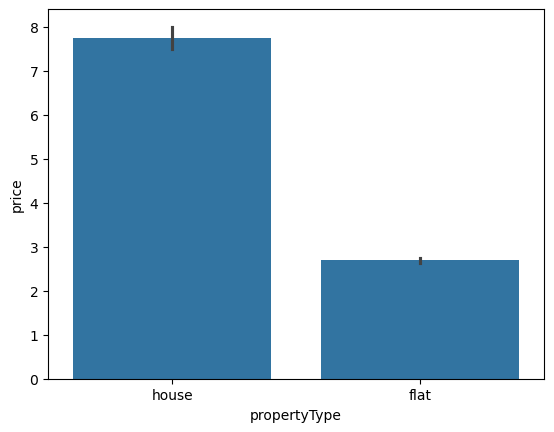

In [7]:
sns.barplot(x = dt['propertyType'] , y = dt['price'],estimator = np.median)

<Axes: xlabel='propertyType', ylabel='price'>

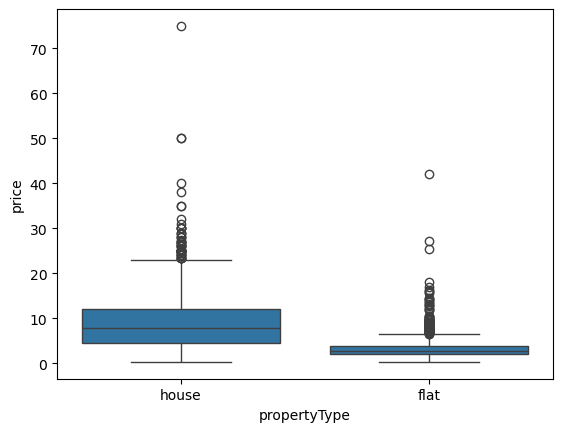

In [8]:
sns.boxplot(x = dt['propertyType'] , y = dt['price'])

# propertyType vs area

<Axes: xlabel='propertyType', ylabel='builtup'>

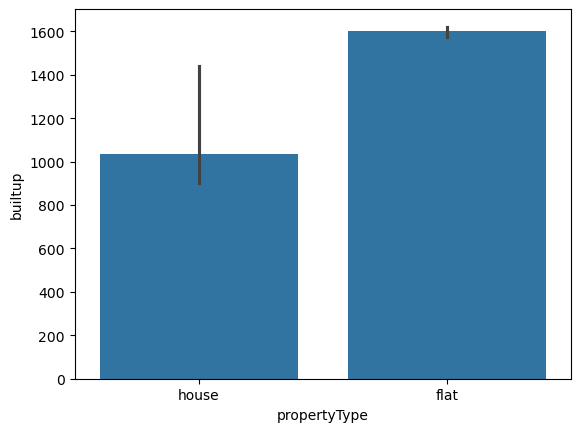

In [53]:
sns.barplot(x = dt['propertyType'] , y = dt['builtup'],estimator = np.median)

    - issue here maybe due to missing values , as the flats builtup is more than house which is not possible

In [49]:
dt['builtup'].isnull().sum()

1253

<Axes: xlabel='propertyType', ylabel='builtup'>

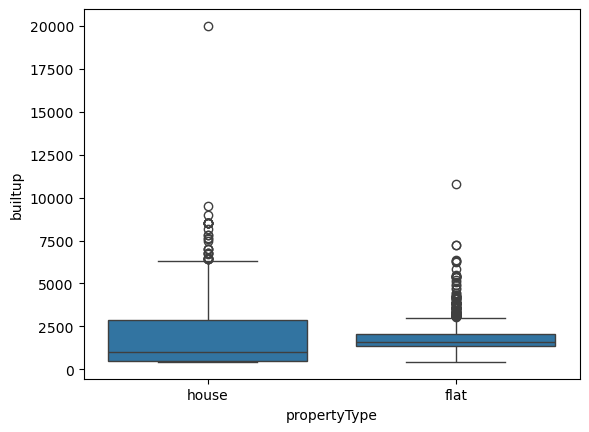

In [51]:
sns.boxplot(x = dt['propertyType'] , y = dt['builtup'])

# propertyType vs pricepersqft

<Axes: xlabel='propertyType', ylabel='pricePerSqft'>

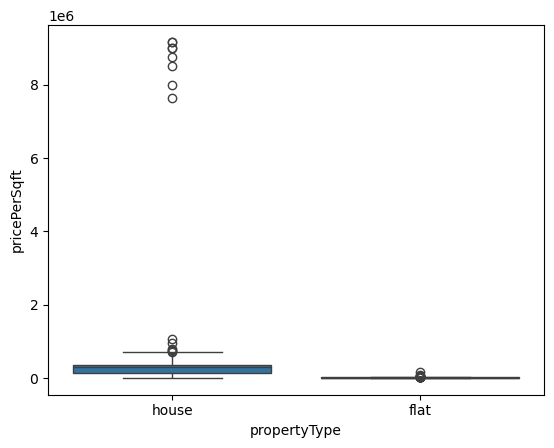

In [56]:
sns.boxplot(x = dt['propertyType'] , y = dt['pricePerSqft'])

<Axes: xlabel='propertyType', ylabel='pricePerSqft'>

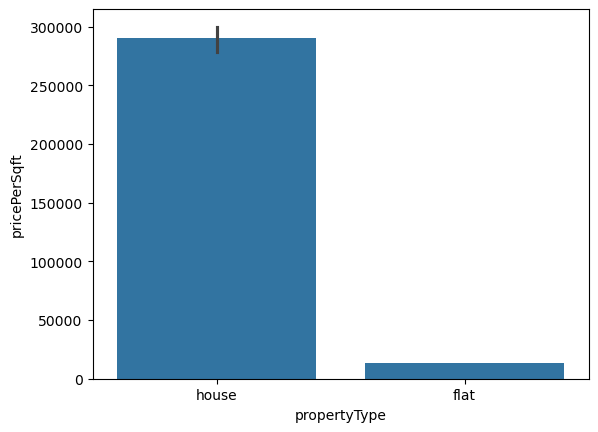

In [62]:
sns.barplot(x = dt['propertyType'] , y = dt['pricePerSqft'],estimator = np.median)

In [66]:
# this is very concerning for houses that this huge price per sqft is not possible
# and the outliers would also not puch much affect as i used median as estimator 
# so ther is issue we need to resolve this 

In [82]:
dt[dt['pricePerSqft']>=10000]

,society,price,sector,pricePerSqft,propertyType,area,superbuilt,carpet,builtup,bedRooms,bathRooms,address,floorNum,facing,agePossesion,balcony,pooja room,servant room,study room,others,store room,furnishType,luxuryScore
0,"palam vihar, gurgaon",4.26,sector 1,24027.07,house,1773.00,2304.900,1507.0500,1773.0000,6.0,6.0,"palam vihar, gurgaon",3.0,north,relatively new property,3,0,0,0,0,0,1,58
2,central park flower valley aqua front towers,2.50,sector 33,13974.29,flat,1789.00,1789.000,1162.8500,1431.2000,3.0,3.0,Central Park Flower Valley Aqua Front Towers S...,5.0,north,relatively new property,NaN,0,0,0,0,1,2,131
3,"sector 45, gurgaon",8.30,sector 45,44647.66,house,1859.00,2416.700,1580.1500,1859.0000,12.0,12.0,"sector 45, gurgaon",4.0,east,new property,3+,1,0,1,0,0,0,198
7,bptp mansions park prime,3.90,sector 66,14109.99,flat,2764.00,2764.000,1934.8000,2349.4000,4.0,4.0,"BPTP Mansions Park Prime Sector 66, Gurgaon",6.0,south,relatively new property,NaN,0,1,0,1,0,2,13
8,tata primanti,4.84,sector 72,18980.39,flat,2550.00,2550.000,1657.5000,2040.0000,3.0,3.0,"Tata Primanti Sector 72, Gurgaon",5.0,north-east,new property,NaN,0,0,0,0,0,1,221
11,tarc maceo,1.93,sector 91,10365.20,flat,1862.00,1862.000,1210.3000,1489.6000,3.0,3.0,"TARC Maceo Sector 91, Gurgaon",6.0,north-east,relatively new property,NaN,0,0,0,0,0,1,103
12,adani m2k oyster grande,2.55,sector 102,13499.21,flat,1889.00,1889.000,1227.8500,1511.2000,3.0,3.0,"Adani M2K Oyster Grande Sector 102, Gurgaon",21.0,north-east,relatively new property,NaN,0,1,0,0,0,2,110
16,shapoorji pallonji joyville gurugram,1.85,sector 102,15226.34,flat,1215.00,1215.000,729.0000,911.2500,2.0,2.0,Shapoorji Pallonji Joyville Gurugram Sector 10...,6.0,north-east,relatively new property,NaN,0,0,0,0,0,2,39
17,"independent floor at dlf city, v block dlf p...",5.31,sector 23,36196.32,house,1467.00,1907.100,1246.9500,1467.0000,4.0,5.0,"independent floor at dlf city, v block dlf p...",2.0,east,relatively new property,3,0,1,0,0,0,1,190
18,ats triumph,3.80,sector 104,12063.49,flat,3150.00,3150.000,2205.0000,2677.5000,4.0,4.0,"ATS Triumph Sector 104, Gurgaon",8.0,east,relatively new property,NaN,0,1,1,0,0,1,107


    - the problem was in case where area was nan , when we divided for per sq feet price
    - price/area it gave huge garbage values 
    - so we need to drop them 

In [71]:
dt['pricePerSqft'] = dt['pricePerSqft'].mask(dt['area'].isnull() , np.nan)

<Axes: xlabel='propertyType', ylabel='pricePerSqft'>

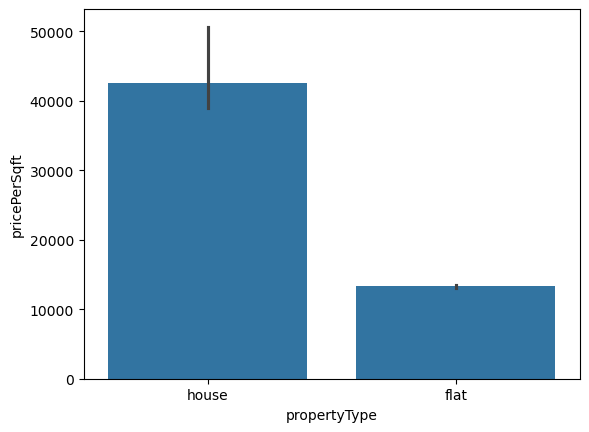

In [73]:
sns.barplot(x = dt['propertyType'] , y = dt['pricePerSqft'] , estimator = np.median)

     - much better but still the price is still too high we need to check for this issue

# propertyType vs bedRoom

In [92]:
pd.crosstab(dt['propertyType'],dt['bedRooms'])

bedRooms,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,22.0,23.0,24.0,26.0,27.0,32.0,36.0,39.0,49.0
propertyType,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
flat,3,349,1254,477,34,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
house,4,58,201,398,344,215,67,47,74,40,19,38,6,3,3,14,1,2,2,7,5,1,3,1,1,2,3,1,1


In [94]:
dt[dt['bedRooms']>=20]

,society,price,sector,pricePerSqft,propertyType,area,superbuilt,carpet,builtup,bedRooms,bathRooms,address,floorNum,facing,agePossesion,balcony,pooja room,servant room,study room,others,store room,furnishType,luxuryScore
141,"sector 45, gurgaon",20.00,sector 45,400000.00,house,500.0,650.0,425.00,500.0,36.0,40.0,"sector 45, gurgaon",5.0,south-east,relatively new property,3+,1,1,1,1,0,0,207
225,"sector 31, gurgaon",8.00,sector 31,NaN,house,NaN,NaN,NaN,NaN,22.0,22.0,"sector 31, gurgaon",4.0,north-east,new property,3+,0,0,0,0,0,0,28
573,"sushant lok phase 1, gurgaon",8.00,sector 43,16842.11,house,4750.0,6175.0,4037.50,4750.0,20.0,20.0,"sushant lok phase 1, gurgaon",5.0,west,new property,3+,0,0,0,0,1,0,148
594,"dlf phase 3, gurgaon",30.00,sector 23,597609.56,house,502.0,652.6,426.70,502.0,24.0,24.0,"dlf phase 3, gurgaon",5.0,north,new property,3+,0,1,0,1,0,0,63
916,"sector 40, gurgaon",14.00,sector 40,NaN,house,NaN,NaN,NaN,NaN,26.0,26.0,"sector 40, gurgaon",4.0,na,new property,3+,0,0,0,0,0,0,123
944,"sector 38, gurgaon",18.00,sector 38,358565.74,house,502.0,652.6,426.70,502.0,36.0,40.0,"sector 38, gurgaon",4.0,north-west,relatively new property,3+,1,1,1,1,0,0,207
1168,"sector 42, gurgaon",14.25,sector 42,NaN,house,NaN,NaN,NaN,NaN,20.0,22.0,"sector 42, gurgaon",4.0,north-west,new property,3+,0,1,0,0,1,0,120
1269,"garden villas, dlf phase 4, gurgaon",11.90,sector 28,NaN,house,NaN,NaN,NaN,NaN,20.0,20.0,"garden villas, dlf phase 4, gurgaon",4.0,east,relatively new property,3+,1,1,0,0,1,0,165
1694,"block c, sushant lok phase 1, gurgaon",11.50,sector 43,NaN,house,NaN,NaN,NaN,NaN,20.0,20.0,"block c, sushant lok phase 1, gurgaon",4.0,na,relatively new property,3+,0,1,0,0,1,0,46
1819,"vipul world, sector 48, gurgaon",8.50,sector 48,NaN,house,NaN,429.0,NaN,NaN,20.0,20.0,"vipul world, sector 48, gurgaon",4.0,north,new property,3+,0,0,0,1,0,1,63


    - this cant be possible that house is 500 sq ft and has 36 bedrooms so , it is entry error
    - there are other values too like that 

# propertyType vs floornum

<Axes: xlabel='propertyType', ylabel='floorNum'>

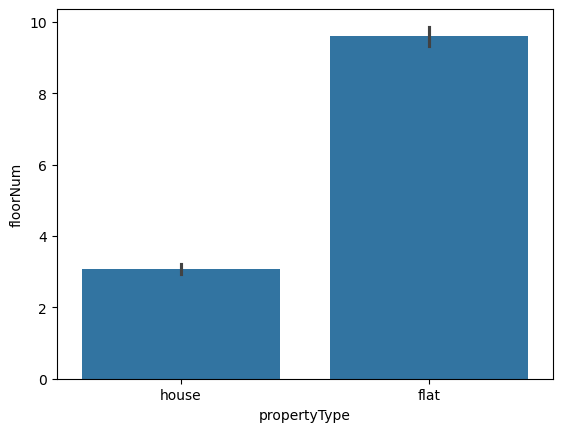

In [103]:
sns.barplot(x=dt['propertyType'],y=dt['floorNum'])

<Axes: xlabel='propertyType', ylabel='floorNum'>

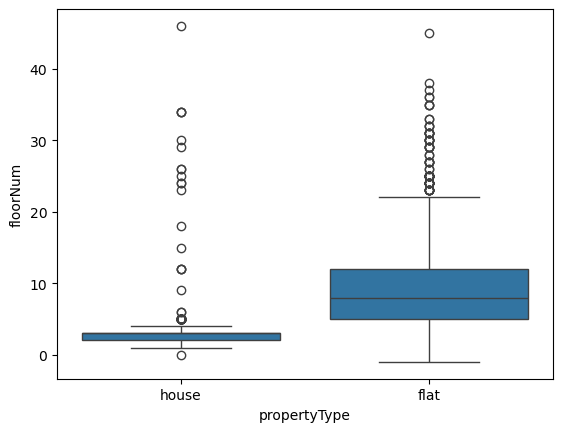

In [105]:
sns.boxplot(x=dt['propertyType'],y=dt['floorNum'])

In [115]:
# how these houses , have 15 plus floors 

In [113]:
dt[(dt['floorNum']>=15)&(dt['propertyType']=='house')]

,society,price,sector,pricePerSqft,propertyType,area,superbuilt,carpet,builtup,bedRooms,bathRooms,address,floorNum,facing,agePossesion,balcony,pooja room,servant room,study room,others,store room,furnishType,luxuryScore
35,"paras dews, sector 106, gurgaon",1.65,sector 106,NaN,house,NaN,NaN,NaN,NaN,2.0,3.0,"paras dews, sector 106, gurgaon",24.0,east,relatively new property,2,1,0,0,0,0,1,207
101,"sector 80, gurgaon",2.69,sector 80,13759.59,house,1955.0,2443.75,1564.00,1955.0,3.0,2.0,"sector 80, gurgaon",34.0,east,under construction,3+,0,0,0,0,0,2,71
154,"conscient heritage one, sector 62, gurgaon",2.90,sector 62,14948.45,house,1940.0,2425.00,1552.00,1940.0,3.0,4.0,"conscient heritage one, sector 62, gurgaon",25.0,east,relatively new property,3,0,0,0,0,0,0,63
169,"paras dews, sector 106, gurgaon",2.15,sector 106,NaN,house,NaN,NaN,NaN,NaN,4.0,3.0,"paras dews, sector 106, gurgaon",23.0,na,relatively new property,3,1,0,1,0,0,1,207
419,"bestech spa signature, sector 81, gurgaon",5.40,sector 81,NaN,house,NaN,NaN,NaN,NaN,4.0,4.0,"bestech spa signature, sector 81, gurgaon",29.0,na,moderatly old property,3+,1,1,1,0,1,2,41
616,"trump tower, sector 65, gurgaon",13.50,sector 65,29670.33,house,4550.0,5915.00,3867.50,4550.0,4.0,4.0,"trump tower, sector 65, gurgaon",46.0,east,new property,3+,0,1,0,0,1,0,207
703,"sector 80, gurgaon",2.70,sector 80,13810.74,house,1955.0,2443.75,1564.00,1955.0,3.0,2.0,"sector 80, gurgaon",34.0,east,under construction,3+,0,0,0,0,0,2,59
1337,"sector 80, gurgaon",2.71,sector 80,13861.89,house,1955.0,2443.75,1564.00,1955.0,3.0,2.0,"sector 80, gurgaon",34.0,east,under construction,3+,0,0,0,0,0,2,67
1720,"shapoorji pallonji joyville gurugram, sector...",1.30,sector 102,13669.82,house,951.0,1141.20,713.25,951.0,2.0,2.0,"shapoorji pallonji joyville gurugram, sector...",24.0,east,new property,2,0,0,0,1,0,0,63
1929,"experion wdchants, sector 112, gurgaon",9.30,sector 112,NaN,house,NaN,NaN,NaN,NaN,4.0,4.0,"experion wdchants, sector 112, gurgaon",26.0,east,relatively new property,2,1,1,1,0,1,1,207


In [121]:
# these , properties are apartments but still called as houses 
# ( we can look it in address as it stated trump tower for example )

<Axes: xlabel='agePossesion', ylabel='propertyType'>

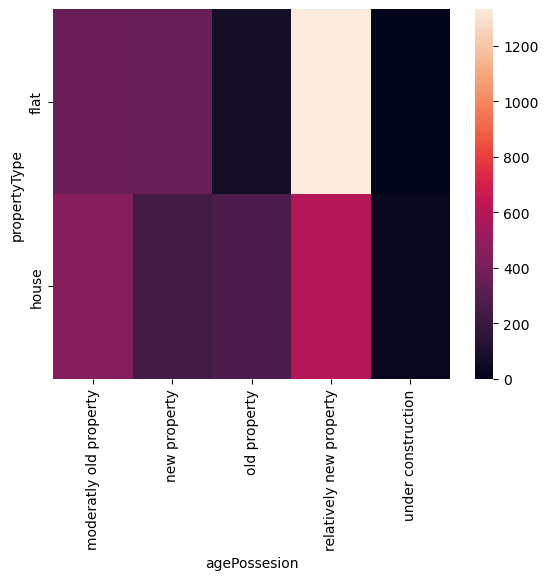

In [127]:
sns.heatmap(pd.crosstab(dt['propertyType'],dt['agePossesion']))

<Axes: xlabel='agePossesion', ylabel='propertyType'>

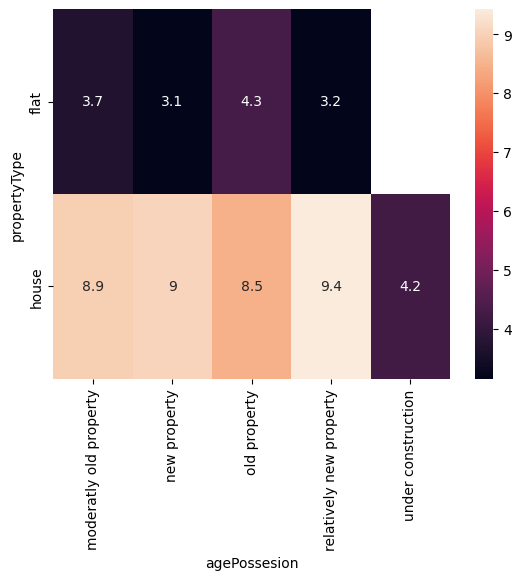

In [145]:
sns.heatmap(pd.pivot_table(dt,index='propertyType',columns='agePossesion',values='price',aggfunc='mean'),annot = True)

<Axes: xlabel='bedRooms', ylabel='propertyType'>

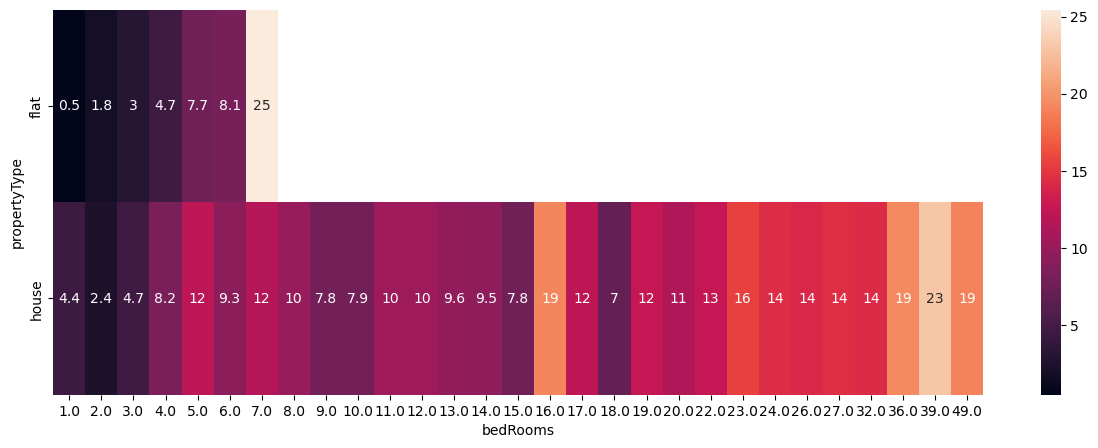

In [157]:
plt.figure(figsize=(15,5))
sns.heatmap(pd.pivot_table(dt,index='propertyType',columns='bedRooms',values='price',aggfunc='mean'),annot=True)

<Axes: xlabel='furnishType', ylabel='propertyType'>

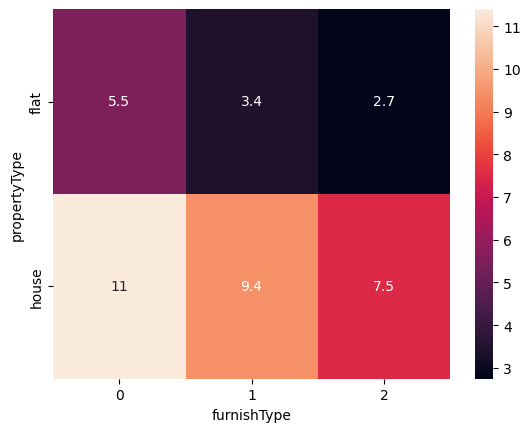

In [161]:
sns.heatmap(pd.pivot_table(dt,index='propertyType',columns='furnishType',values='price',aggfunc='mean'),annot=True)

<Axes: xlabel='propertyType', ylabel='luxuryScore'>

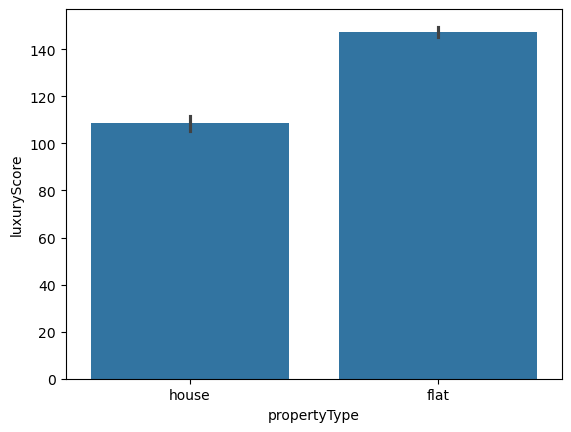

In [165]:
sns.barplot(x=dt['propertyType'],y=dt['luxuryScore'])

<Axes: xlabel='propertyType', ylabel='luxuryScore'>

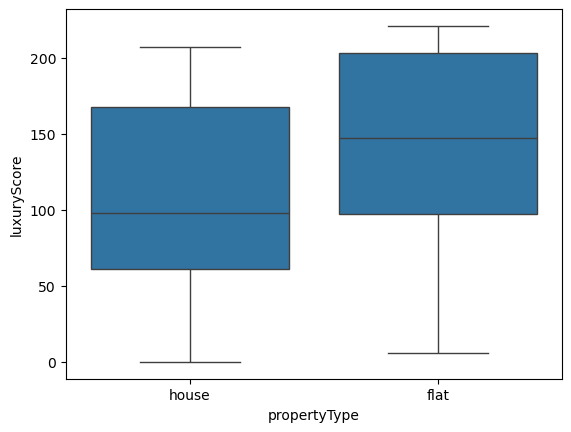

In [167]:
sns.boxplot(x=dt['propertyType'],y=dt['luxuryScore'])

<Axes: xlabel='sector', ylabel='propertyType'>

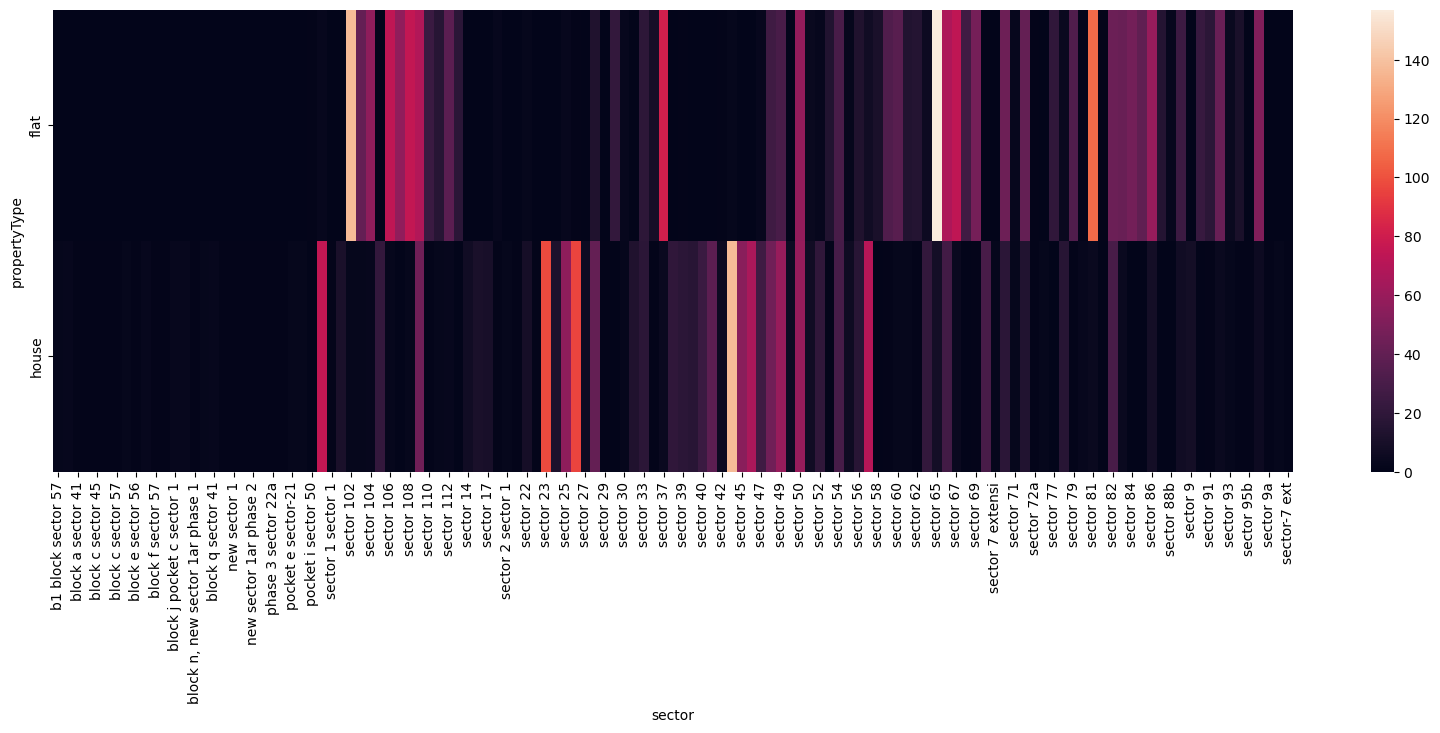

In [209]:
plt.figure(figsize=(20,6))
sns.heatmap(pd.crosstab(dt['propertyType'],dt['sector'].sort_index()))

# Price

<Axes: ylabel='sector'>

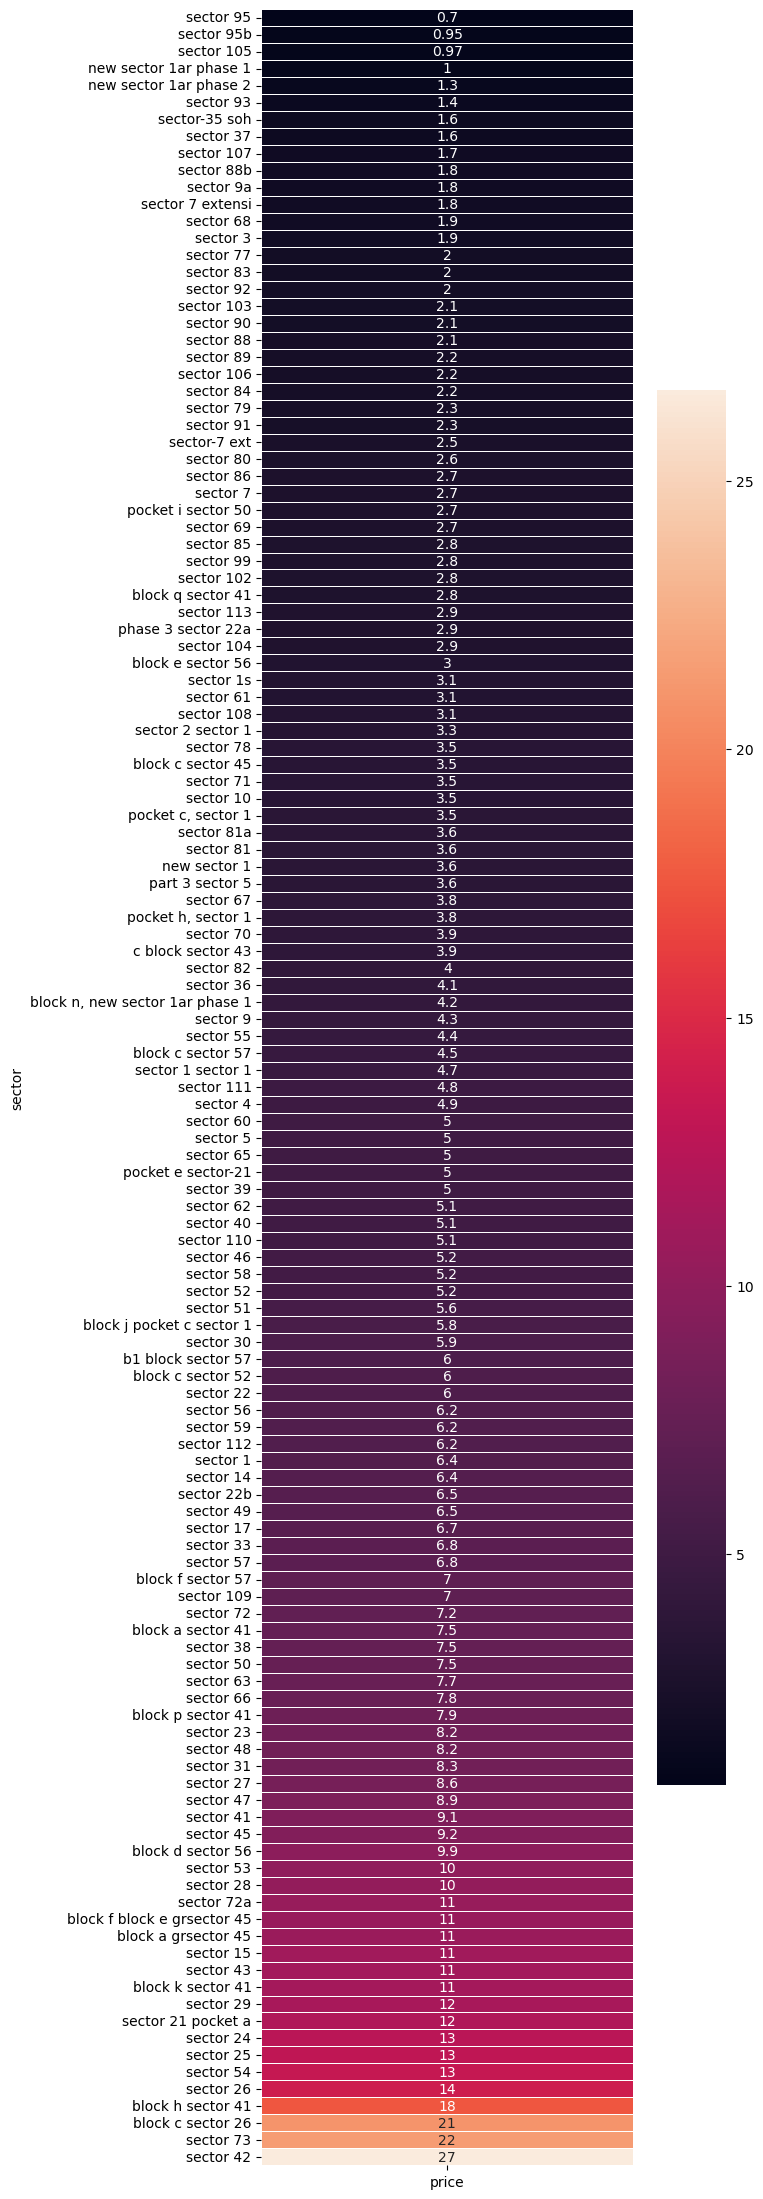

In [294]:
avg_price_per_sector = round(dt.groupby('sector')['price'].mean().sort_values(),2)
plt.figure(figsize=(6,28))
# we need to convert this series to a dataframe as , sns expects a 2D structure , so we used to_frame()
sns.heatmap(avg_price_per_sector.to_frame(),annot=True,linewidths=0.7)

<Axes: ylabel='sector'>

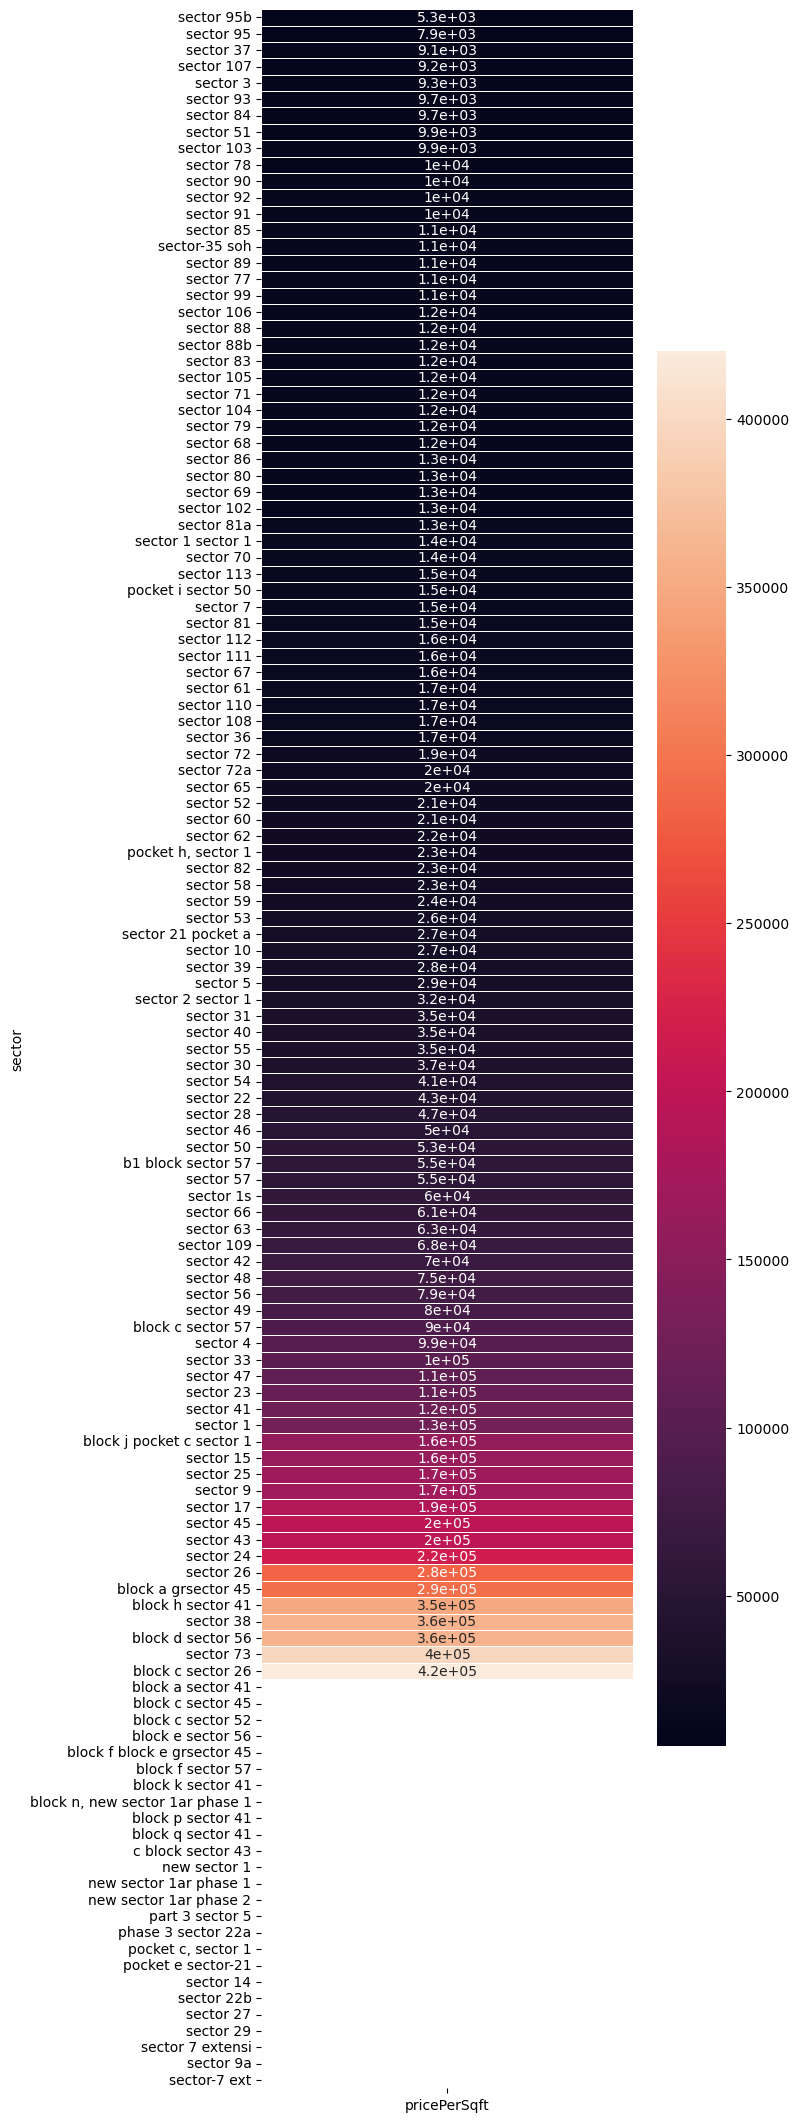

In [336]:
avg_price_per_sqft_per_sector = round(dt.groupby('sector')['pricePerSqft'].mean().sort_values(),2)
plt.figure(figsize=(6,27))
sns.heatmap(avg_price_per_sqft_per_sector.to_frame(),annot=True,linewidths=0.7)

<Axes: ylabel='sector'>

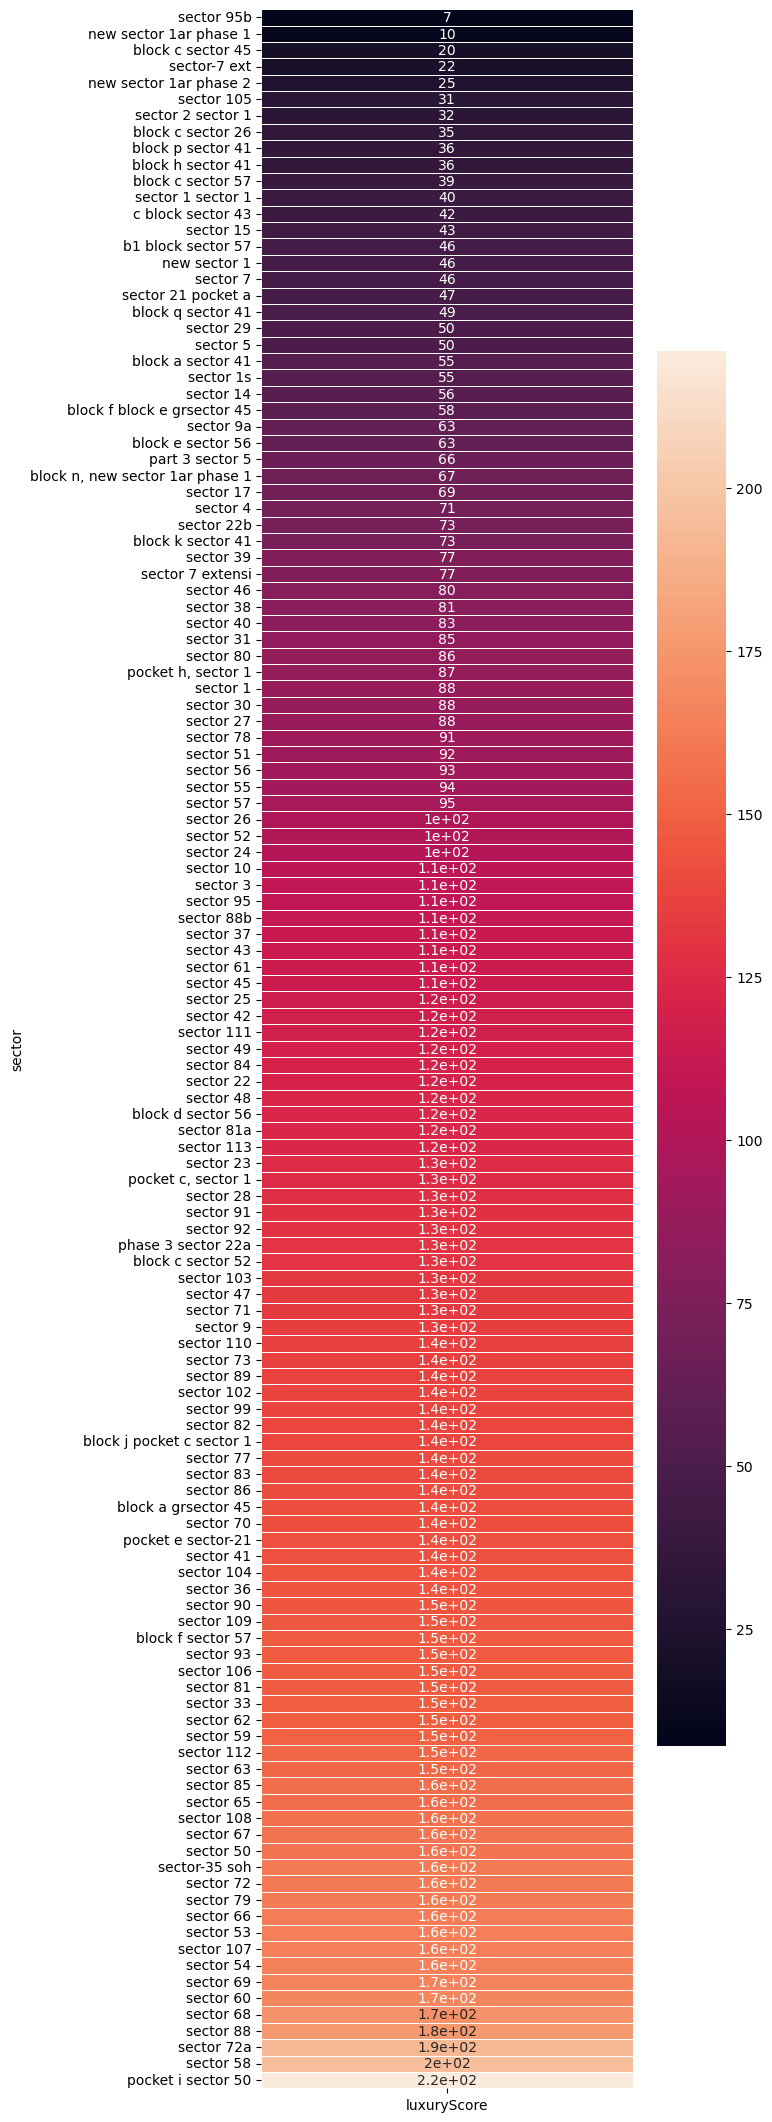

In [341]:
avg_price_per_sqft_per_sector = round(dt.groupby('sector')['luxuryScore'].mean().sort_values(),2)
plt.figure(figsize=(6,27))
sns.heatmap(avg_price_per_sqft_per_sector.to_frame(),annot=True,linewidths=0.7)

<Axes: xlabel='area', ylabel='price'>

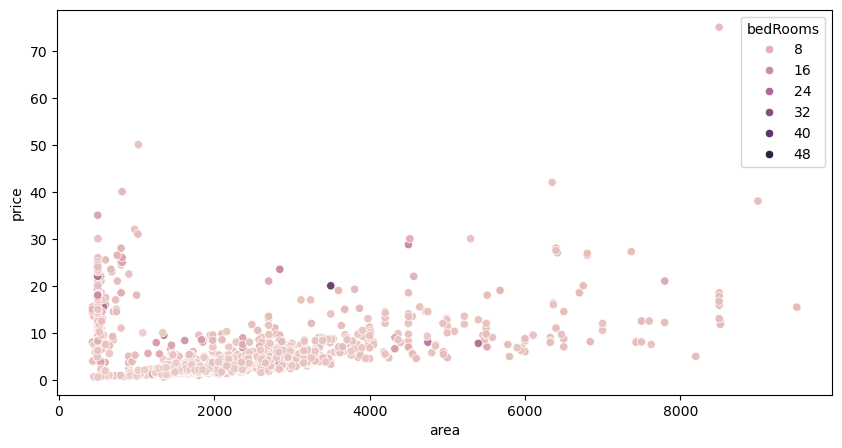

In [383]:
plt.figure(figsize=(10,5))
sns.scatterplot(x = dt[dt['area']<10000]['area'], y = dt['price'],hue=dt['bedRooms'])

<Axes: xlabel='area', ylabel='price'>

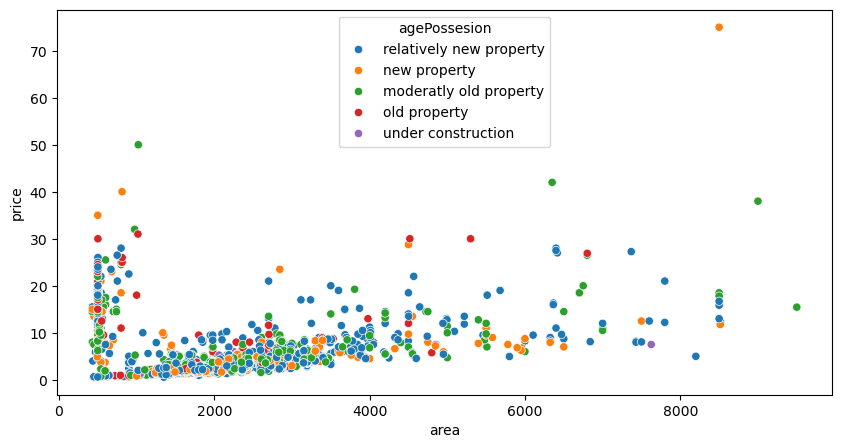

In [389]:
plt.figure(figsize=(10,5))
sns.scatterplot(x = dt[dt['area']<10000]['area'], y = dt['price'],hue=dt['agePossesion'])

<Axes: xlabel='area', ylabel='price'>

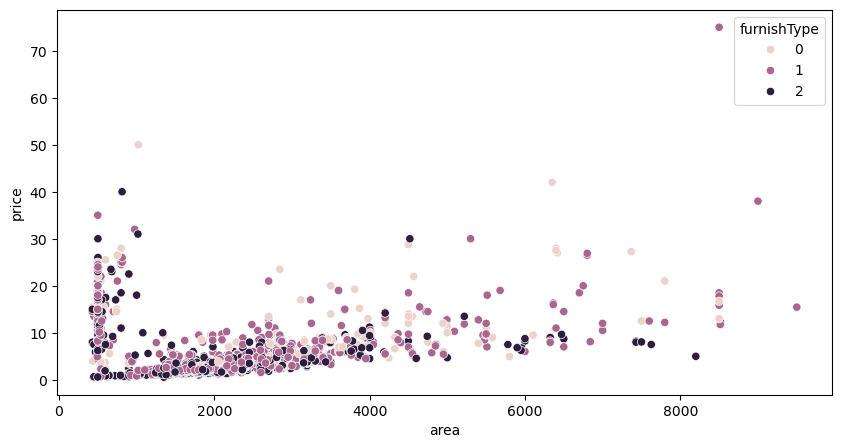

In [393]:
plt.figure(figsize=(10,5))
sns.scatterplot(x = dt[dt['area']<10000]['area'], y = dt['price'],hue=dt['furnishType'])

/var/folders/gy/lt_77nr13fs5zj9y4gdv7v4r0000gn/T/ipykernel_6162/3096980168.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dt['agePossesion'],y=dt['price'],estimator=np.median,palette='plasma')


([0, 1, 2, 3, 4],
 [Text(0, 0, 'relatively new property'),
  Text(1, 0, 'new property'),
  Text(2, 0, 'moderatly old property'),
  Text(3, 0, 'old property'),
  Text(4, 0, 'under construction')])

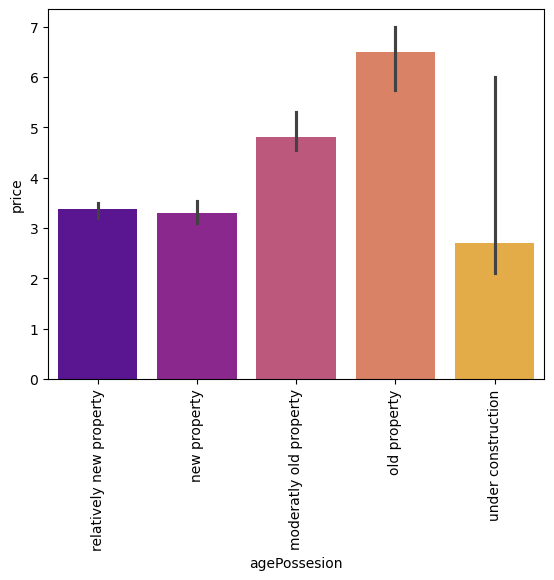

In [411]:
sns.barplot(x=dt['agePossesion'],y=dt['price'],estimator=np.median,palette='plasma')
plt.xticks(rotation = 'vertical')

<Axes: xlabel='luxuryScore', ylabel='price'>

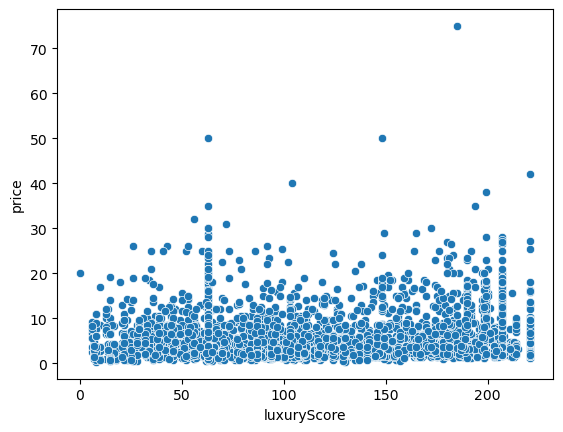

In [419]:
sns.scatterplot(x=dt['luxuryScore'],y=dt['price'])

# correlation

<Axes: >

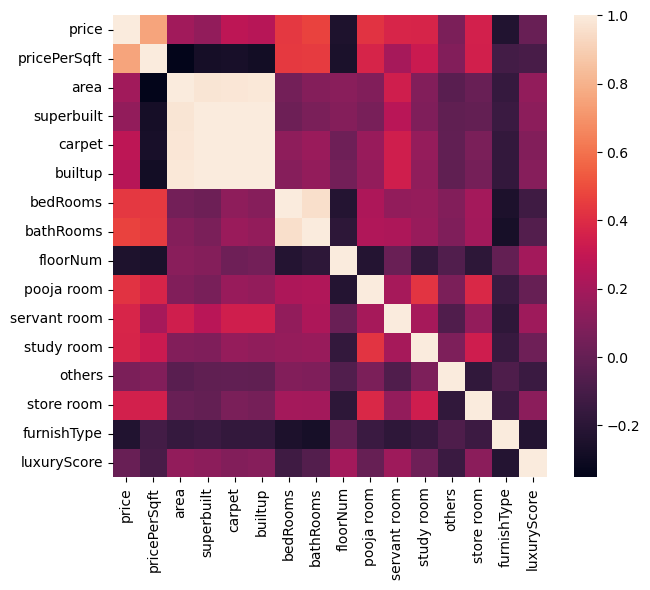

In [454]:
plt.figure(figsize=(7,6))
sns.heatmap(dt.select_dtypes(np.number).corr())

In [458]:
dt.select_dtypes(np.number).corr()['price']

price           1.000000
pricePerSqft    0.755521
area            0.188245
superbuilt      0.139737
carpet          0.277813
builtup         0.258642
bedRooms        0.434696
bathRooms       0.470911
floorNum       -0.243766
pooja room      0.422246
servant room    0.374172
study room      0.367061
others          0.071721
store room      0.353109
furnishType    -0.231148
luxuryScore     0.009236
Name: price, dtype: float64